# Week 5 - Optimization Models for Picking Loans

This notebook carries out the following steps
  1. Read the saved pickle data and prepares it for analysis and load the classification models for default probability and regression models for returns
  2. Uses them to implement the baseline strategies from last week
  3. Uses the predicted default probabilities and returns in an optimization model to pick a set of loans to invest in (You can compare the optimization based portfolios to the strategies from last week)
  4. Performs a sensitivity analysis of the performance of the loan portfolio by re-solving the optimization models for various levels of risk

Things for you to do
- Change the number of clusters based on your assessment.
- Use the best model for predicting the returns of your chosen method from the last module and replace the regressionl model here with that.
- You can output any additional fields about the test loans you may want to examine later if they will help you explain your final loans picked by your optimization model.

Prepare your presentation. Your presentation should contain about at most 6 slides. Add an extra slide at the end if you tried the BONUS.
1. Begin by stating the objective of the presentation and what your objective is. Which questions do you seek to answer? What are the main points of the presentation?
2. (& 3) Describe the final portfolio that you obtained. What variable did you optimize for? Which constraints did you impose? Which method from the last module did you use to predict returns? What are the grades of the selected loans?
4. Compare the portfolio that you obtained with the one obtained in module 4. Which metrics are you using to compare them? You may want to consider factors such as risk, probability of default, returns and scalability.
5. State your conclusions. What is the main idea you wish to convey with the presentation? Based on the last two models, how should Jasmine invest her money? 

BONUS
- Do you think it is better to use the loan risk as we did in this script or to use the probability of default from Module 3? Implement a new optimization model using probability of default. Clearly explain your model and discuss its pros and cons. How does this new method compare to the one you obtained in this script? 
- Split your data set between short term and long-term loans. Re-compute this script for the two types of loans. Do you get better results?

In [1]:
# Load general utilities
# ----------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import datetime
import numpy as np
import pickle
import time
import seaborn as sns

# Load sklearn utilities
# ----------------------
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, brier_score_loss, mean_squared_error, r2_score

from sklearn.calibration import calibration_curve

# Load classifiers
# ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier

# Other Packages
# --------------
from scipy.stats import kendalltau
from sklearn.neural_network import MLPRegressor
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
## from gurobipy import *
from six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
#from scipy.interpolate import spline

# Load debugger, if required
#import pixiedust
pd.options.mode.chained_assignment = None #'warn'

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")

## 5.1 Load saved models.
Load the dictionary first, assign value when we need to.

In [2]:
# read saved models
#infile = open('/Users/hrishikeshharishkumar/Documents/CMU Tepper - MSBA/Mini 1 - Fall 2023/Business Value through Integrative Analytics/Update 4 - Prescriptive Modeling - Ranking Using Predictors/saved models/week4_saved_models','rb')
infile = open('/Users/hrishikeshharishkumar/Documents/CMU Tepper - MSBA/Mini 1 - Fall 2023/Business Value through Integrative Analytics/Update 4 - Prescriptive Modeling - Ranking Using Predictors/sm/week4_saved_models_Sep30','rb')
saved_models = pickle.load(infile)
infile.close()
print('models loaded:', saved_models.keys())

# save into a new dict if there is anything new to save
models_to_save = saved_models.copy()

models loaded: dict_keys(['rf1213', 'reg_rf1213', 'reg_rf_separate1213', 'reg_mlp1213', 'l1_logistic1213'])


## 5.2 Build and test baseline investment strategies
Now we test several investment strategies using the learning models above

In [3]:
default_seed = 1
output_file = "output_sample"

In [4]:
# Create a function to print a line to our output file
def dump_to_output(key, value):
    with open(output_file, "a") as f:
        f.write(",".join([str(default_seed), key, str(value)]) + "\n")

In [5]:
def test_investments(data_dict,
                        classifier = None,
                        regressor = None,
                        strategy = 'Random',
                        num_loans = 1000,
                        random_state = default_seed,
                        output_to_file = True):
    '''
    This function tests a variety of investment methodologies and their returns.
    It will run its tests on the loans defined by the test_set element of the data
    dictionary.

    It is currently able to test four strategies
      - random: invest in a random set of loans
      - ranking: score each loan by probability of default, and only invest
                 in the "safest" loans (i.e., those with the lowest probabilities
                 of default)
      - regression: train a single regression model to predict the expected return
                    of loans in the past. Then, for loans we could invest in, simply
                    rank them by their expected returns and invest in that order.
      - two-stage: train two regression models to predict the expected return of
                   defaulted loans and non-defaulted loans in the training set. Then,
                   for each potential loan we could invest in, predict the probability
                   the loan will default, its return if it doesn't default and its
                   return if it does. Then, calculate a weighted combination of
                   the latter using the former to find a predicted return. Rank the
                   loans by this expected return, and invest in that order

    It expects the following parameters
      - data_dict: the dictionary containing both training and testing data;
                   returned by the prepare_data function
      - classifier: a fitted model object which is returned by the fit_classification function.
      - regressor: a fitted model object which is returned by the fit_regression function.
      - strategy: the name of the strategy; one of the three listed above
      - num_loans: the number of loans to be included in the test portfolio
      - num_samples: the number of random samples used to compute average return ()
      - random_state: the random seed to use when selecting a subset of rows
      - output_to_file: if the results will be saved to the output file

    The function returns a dictionary FOR EACH RETURN DEFINITION with the following entries
      - strategy: the name of the strategy
      - average return: the return of the strategy based on the testing set
      - test data: the updated Dataframe of testing data. Useful in the optimization section
    '''

    np.random.seed(random_state)

    # Retrieve the rows that were used to train and test  the
    # classification model
    train_set = data_dict['train_set']
    test_set = data_dict['test_set']

    col_list = ['ret_PESS', 'ret_OPT', 'ret_INTa', 'ret_INTb']

    # Create a dataframe for testing, including the score
    data_test = data.loc[test_set,:]
    out = {}

    for ret_col in col_list:

        if strategy == 'Random':
            # Randomize the order of the rows in the datframe
            data_test = data_test.sample(frac = 1).reset_index(drop = True)

            # Select num_loans to invest in
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]

            # Find the average return for these loans
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue

        elif strategy == 'Regression':

            colname = 'predicted_return_' + ret_col

            data_test[colname] = regressor[ret_col]['predicted_return']

            # Sort the loans by predicted return
            data_test = data_test.sort_values(by=colname, ascending = False).reset_index(drop = True)

            # Pick num_loans loans
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            # Find their return
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'test data':data_test,'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue

        # Get the predicted scores, if the strategy is not Random or just Regression
        try:
            y_pred_score = classifier['y_pred_probs']
        except:
            y_pred_score = classifier['y_pred_score']

        data_test['score'] = y_pred_score


        if strategy == 'Ranking':
            # Sort the test data by the score
            data_test = data_test.sort_values(by='score').reset_index(drop = True)

            # Select num_loans to invest in
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            # Find the average return for these loans
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test,'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue


        elif strategy == 'Two-stage':

            # Load the predicted returns
            data_test['predicted_regular_return'] = regressor[ret_col]['predicted_regular_return']
            data_test['predicted_default_return'] = regressor[ret_col]['predicted_default_return']

            # Compute expectation
            colname = 'predicted_return_' + ret_col

            data_test[colname] = ( (1-data_test.score)*data_test.predicted_regular_return +
                                             data_test.score*data_test.predicted_default_return )

            # Sort the loans by predicted return
            data_test = data_test.sort_values(by=colname, ascending = False).reset_index(drop = True)

            # Pick num_loans loans
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            # Find their return
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'test data':data_test, 'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue
            
        elif strategy == 'Greedy':
            
            colname = 'predicted_return_' + ret_col

            data_test[colname] = regressor[ret_col]['predicted_return']


            # Sort the loans by return-to-risk ratio:
            #temp1 = data_test.ret_OPT.to_numpy() # return
            temp1 = data_test[colname] 
            temp2 = data_test['score'].to_numpy() # default probability
            data_test['ratio'] = temp1/temp2
            data_test = data_test.sort_values(by='ratio', ascending = False).reset_index(drop = True)

            # Pick num_loans loans
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            # Find their return
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test,'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue

        elif strategy == 'Crystal-ball':

            # Sort the loans by realized return
            data_test = data_test.sort_values(by=ret_col, ascending = False).reset_index(drop = True)

            # Pick num_loans loans
            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            # Find their return
            ret_test = np.dot(pf_test[ret_col],pf_test.funded_amnt)/np.sum(pf_test.funded_amnt)

            # Return
            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'pf_test':pf_test}

            # Dump the strategy performance to file
            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test )

            continue

        elif strategy == 'Innovative':

            min_interest_rate = 10.0 
            selected_grades = ['A', 'B', 'C'] 

            filtered_data = data_test[(data_test['int_rate'] > min_interest_rate) &
                                  (data_test['grade'].isin(selected_grades))]

            filtered_data = filtered_data.sort_values(by=ret_col, ascending=False).reset_index(drop=True)


            pf_test = data_test[['loan_amnt','funded_amnt',ret_col, 'grade','default','int_rate', 'annual_inc', 'dti', 'term',  'revol_bal', 'revol_util', 'inq_last_6mths','pct_tl_nvr_dlq', 'cr_hist', 'outcome']].iloc[:num_loans]


            ret_test = np.dot(pf_test[ret_col], pf_test.funded_amnt) / np.sum(pf_test.funded_amnt)


            out[ret_col] = {'strategy': strategy, 'average return': ret_test, 'pf_test':pf_test}


            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test)

            continue

        else:
            return 'Not a valid strategy'

    return out

In [6]:
# 1. Load the data and engineer the features
## 1.1 Load data

# Read the data and features from the pickle
data, discrete_features, continuous_features, ret_cols = pickle.load( open( "/Users/hrishikeshharishkumar/CMU Mini 1 - Fall 2023 - Business Value through Integrative Analytics/Update 2: Diagnostic and Descriptive Analysis/PickleData/ret_data_Sep28.pickle", "rb" ) )


weights = {'Fully Paid' : 1, 'Charged Off' : 3, 'Default' : 2}

data['weights'] = data['loan_status'].apply(lambda x:weights[x])

data = data.sample(n=150000, weights = 'weights', random_state =123)

# Create the outcome
data["outcome"] = data.loan_status.isin(["Charged Off", "Default"])

# Create a feature for the length of a person's credit history at the
# time the loan is issued
data['cr_hist'] = (data.issue_d - data.earliest_cr_line) / np.timedelta64(1, 'M')
continuous_features.append('cr_hist')

# Randomly assign each row to a training and test set. We do this now
# because we will be fitting a variety of models on various time periods,
# and we would like every period to use the *same* training/test split
np.random.seed(default_seed)
data['train'] = np.random.choice([True, False], size = len(data), p = [0.7, 0.3])




In [7]:
discrete_features.remove('verification_status')

In [8]:
discrete_features.remove('home_ownership')

In [9]:
discrete_features.remove('purpose')
continuous_features.remove('pct_tl_nvr_dlq')
continuous_features.remove('total_acc')
continuous_features.remove('tot_coll_amt')


In [10]:
continuous_features.remove('funded_amnt_inv')

In [11]:
discrete_features

['emp_length', 'term', 'grade']

In [12]:
continuous_features

['loan_amnt',
 'funded_amnt',
 'installment',
 'annual_inc',
 'dti',
 'revol_bal',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'tot_cur_bal',
 'bc_util',
 'inq_last_6mths',
 'int_rate',
 'revol_util',
 'cr_hist']

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150000 entries, 163368 to 16951
Data columns (total 42 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_amnt            150000 non-null  float64
 1   funded_amnt          150000 non-null  float64
 2   term                 150000 non-null  object 
 3   int_rate             150000 non-null  float64
 4   installment          150000 non-null  float64
 5   grade                150000 non-null  object 
 6   emp_length           142142 non-null  object 
 7   home_ownership       150000 non-null  object 
 8   annual_inc           150000 non-null  float64
 9   verification_status  150000 non-null  object 
 10  issue_d              150000 non-null  object 
 11  loan_status          150000 non-null  object 
 12  purpose              150000 non-null  object 
 13  dti                  150000 non-null  float64
 14  delinq_2yrs          150000 non-null  float64
 15  earliest_cr_l

In [14]:
# Create a matrix of features and outcomes, with dummies. Record the
# names of the dummies for later use
X_continuous = data[continuous_features].values

X_discrete = pd.get_dummies(data[discrete_features], dummy_na = True, prefix_sep = "::", drop_first = True)
discrete_features_dummies = X_discrete.columns.tolist()
X_discrete = X_discrete.values

X = np.concatenate( (X_continuous, X_discrete), axis = 1 )

y = data.outcome.values

train = data.train.values

<Axes: >

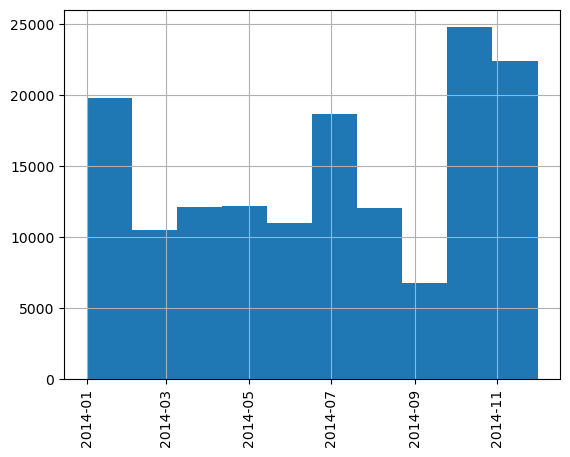

In [15]:
# take a look at distribution in date to decide 
# the size of train and test set splitted by time

data['issue_d'].hist(xrot=90)

In [16]:
# fund out cut off date to divide the data into ~70% traininig data and ~30% testing data
date_threshold = np.quantile(data['issue_d'],5/7)

In [17]:
## 1.2 Prepare functions to fit and evaluate models

def prepare_data(data_subset = np.array([True]*len(data)),
                    n_samples_train = 20000,
                    n_samples_test = 10000,
                    feature_subset = None,
                    date_range_train = (data.issue_d.min(), date_threshold),
                    date_range_test = (date_threshold, data.issue_d.max()),
                    random_state = default_seed):
    '''
    This function will prepare the data for classification or regression.
    It expects the following parameters:
      - data_subset: a numpy array with as many entries as rows in the
                     dataset. Each entry should be True if that row
                     should be used, or False if it should be ignored
      - n_samples_train: the total number of samples to be used for training.
                         Will trigger an error if this number is larger than
                         the number of rows available after all filters have
                         been applied
      - n_samples_test: as above for testing
      - feature_subect: A list containing the names of the features to be
                        used in the model. In None, all features in X are
                        used
      - date_range_train: a tuple containing two dates. All rows with loans
                          issued outside of these two dates will be ignored in
                          training
      - date_range_test: as above for testing
      - random_state: the random seed to use when selecting a subset of rows
      
    Note that this function assumes the data has a "Train" column, and will
    select all training rows from the rows with "True" in that column, and all
    the testing rows from those with a "False" in that column.
    
    This function returns a dictionary with the following entries
      - X_train: the matrix of training data
      - y_train: the array of training labels
      - train_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the train set
      - X_test: the matrix of testing data
      - y_test: the array of testing labels
      - test_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the test set
    '''
    
    np.random.seed(random_state)
        
    # Filter down the data to the required date range, and downsample
    # as required
    filter_train = ( train & (data.issue_d >= date_range_train[0]) &
                            (data.issue_d <= date_range_train[1]) & data_subset ).values
    filter_test = ( (train == False) & (data.issue_d >= date_range_test[0])
                            & (data.issue_d <= date_range_test[1]) & data_subset ).values
    
    filter_train[ np.random.choice( np.where(filter_train)[0], size = filter_train.sum() 
                                   - n_samples_train, replace = False ) ] = False
    filter_test[ np.random.choice( np.where(filter_test)[0], size = filter_test.sum() 
                                   - n_samples_test, replace = False ) ] = False
    
    # Prepare the training and test set
    X_train = X[ filter_train , :]
    X_test = X[ filter_test, :]
    if feature_subset != None:
        cols = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in feature_subset]
        X_train = X_train[ : , cols ]
        X_test = X_test[ : , cols ]
        
    y_train = y[ filter_train ]
    y_test = y[ filter_test ]
    
    # Scale the variables
    scaler = preprocessing.MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # return training and testing data
    out = {'X_train':X_train, 'y_train':y_train, 'train_set':filter_train, 
           'X_test':X_test, 'y_test':y_test, 'test_set':filter_test}
    
    return out

## Implement the test strategies on 2012-13 data

In [18]:
## read saved models
reg_rf1213 = saved_models['reg_rf1213']
rf1213 = saved_models['rf1213']

In [19]:
# Randomly assign each row to a training and test set. We do this now
# because we will be fitting a variety of models on various time periods,
# and we would like every period to use the *same* training/test split
#np.random.seed(default_seed)
#data['train'] = np.random.choice([True, False], size = len(data), p = [0.7, 0.3])

In [20]:
final_features = [i for i in discrete_features + continuous_features]
data_dict = prepare_data(feature_subset = final_features)

all_features = pd.Series(continuous_features + discrete_features_dummies)
idx = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in final_features]
selected_features = all_features[idx]
selected_features.reset_index(drop=True,inplace=True)

In [21]:
final_features

['emp_length',
 'term',
 'grade',
 'loan_amnt',
 'funded_amnt',
 'installment',
 'annual_inc',
 'dti',
 'revol_bal',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'tot_cur_bal',
 'bc_util',
 'inq_last_6mths',
 'int_rate',
 'revol_util',
 'cr_hist']

### 5.2.1 Random

In [22]:
#col_list = ['ret_PESS', 'ret_OPT', 'ret_INTa', 'ret_INTb']
col_list = ['ret_OPT']
test_strategy = 'Random'

print('strategy:',test_strategy)   
strat_random = test_investments(data_dict,strategy = test_strategy, 
                            num_loans = 100, output_to_file = False, random_state = 1)
for ret_col in col_list:
    print(ret_col + ': ' + str(strat_random[ret_col]['average return']))
    print(str(strat_random[ret_col]['pf_test']))

strategy: Random
ret_OPT: 0.056861438898647754
    loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
0     28000.0      28000.0  0.053933     A        0      7.69     90000.0   
1     12000.0      12000.0  0.146024     D        0     17.57     34076.0   
2     27000.0      27000.0  0.098212     B        0     12.49     85086.0   
3     16750.0      16750.0  0.190709     E        0     18.99     42000.0   
4     21000.0      21000.0  0.074525     C        0     13.66    114000.0   
..        ...          ...       ...   ...      ...       ...         ...   
95    24000.0      24000.0  0.061809     B        0     11.44    118000.0   
96    20325.0      20325.0  0.070739     B        0     11.99     60000.0   
97     7200.0       7200.0  0.137329     C        0     13.98     54000.0   
98    24000.0      24000.0 -0.141339     B        1      9.49     72000.0   
99    13500.0      13500.0  0.048567     A        0      6.49     52500.0   

      dti        term  revol

In [23]:
strat_random['ret_OPT']['pf_test'].to_csv('random_OCT8.csv')

### 5.2.2 Ranking

In [24]:
test_strategy = 'Ranking'

print('strategy:',test_strategy)
strat_rank = test_investments(data_dict, classifier=rf1213, strategy = test_strategy, 
                        num_loans = 100, output_to_file = False)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_rank[ret_col]['average return']))
    print(str(strat_rank[ret_col]['pf_test']))

strategy: Ranking
ret_OPT: 0.03134949496448891
    loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
0      9000.0       9000.0  0.088038     D        0     16.29    30000.00   
1     10800.0      10800.0 -0.110022     E        1     20.20    36000.00   
2     18000.0      18000.0  0.080006     B        0     11.44    75000.00   
3     24000.0      24000.0  0.114210     D        0     15.61   100000.00   
4     12000.0      12000.0  0.047090     B        0      8.67    65000.00   
..        ...          ...       ...   ...      ...       ...         ...   
95     6000.0       6000.0  0.043440     A        0      8.19    50874.12   
96     7000.0       7000.0  0.156466     E        0     18.54    25000.00   
97     7500.0       7500.0  0.070557     C        0     12.99    65000.00   
98     9100.0       9100.0  0.084702     D        0     16.99    80000.00   
99    10000.0      10000.0  0.074390     C        0     13.98    43350.00   

      dti        term  revol

In [25]:
strat_rank['ret_OPT']['pf_test'].to_csv('ranking_OCT8.csv')

### 5.2.3 Regression

In [26]:
test_strategy = 'Regression'

print('strategy:',test_strategy)
strat_reg = test_investments(data_dict, regressor=reg_rf1213, strategy = test_strategy, 
                        num_loans = 100)
for ret_col in col_list:
    print(ret_col + ': ' + str(strat_reg[ret_col]['average return']))
    print(str(strat_reg[ret_col]['pf_test']))

strategy: Regression
ret_OPT: 0.052792297528208465
    loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
0      4000.0       4000.0  0.010078     C        1     14.99     36000.0   
1     30000.0      30000.0  0.105896     D        0     18.24    103503.0   
2     30000.0      30000.0  0.083798     B        0      9.49    115000.0   
3     27600.0      27600.0  0.076662     C        0     13.98     70000.0   
4     10000.0      10000.0 -0.069358     D        1     17.57     39000.0   
..        ...          ...       ...   ...      ...       ...         ...   
95    15000.0      15000.0  0.036395     A        0      6.99    108150.0   
96    18000.0      18000.0  0.068036     B        0     12.49     50000.0   
97     9000.0       9000.0  0.031718     A        0      6.03     62000.0   
98    35000.0      35000.0 -0.082202     D        1     16.49     75000.0   
99    12000.0      12000.0  0.116557     D        0     16.49     30000.0   

      dti        term  r

In [27]:
strat_reg['ret_OPT']['pf_test'].to_csv('regression_OCT8.csv')

### 5.2.4 Two-stage
#### Compute random forest regression:

In [28]:
## load model
reg_rf_separate1213 = saved_models['reg_rf_separate1213']
l1_logistic1213 = saved_models['l1_logistic1213']

#### test two-stage stratgy

In [29]:
test_strategy = 'Two-stage'
#rf1213
#l1_logistic1213
print('strategy:',test_strategy)
two_stage = test_investments(data_dict, classifier = l1_logistic1213, regressor = reg_rf_separate1213, 
                             strategy = test_strategy, num_loans = 100)


for ret_col in col_list:
    print(ret_col + ': ' + str(two_stage[ret_col]['average return']))
    print(str(two_stage[ret_col]['pf_test']))

strategy: Two-stage
ret_OPT: 0.04476399919513074
    loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
0      5000.0       5000.0 -0.042827     C        1     14.49     33000.0   
1      3000.0       3000.0  0.046820     A        0      7.12     52000.0   
2     20000.0      20000.0  0.042769     A        0      6.49     60000.0   
3     35000.0      35000.0  0.107612     E        0     19.24     70000.0   
4      6825.0       6825.0  0.102248     C        0     14.99     50000.0   
..        ...          ...       ...   ...      ...       ...         ...   
95     9750.0       9750.0 -0.125117     D        1     16.29     56000.0   
96    15500.0      15500.0 -0.115987     D        1     15.59     43000.0   
97    11875.0      11875.0  0.000694     E        1     19.52     35000.0   
98    15000.0      15000.0  0.159870     D        0     17.57     57491.0   
99    28425.0      28425.0  0.089345     D        0     15.61    129020.0   

      dti        term  rev

In [30]:
two_stage['ret_OPT']['pf_test'].to_csv('twostage_OCT8.csv')

### 5.2.5 Greedy

In [31]:
l1_logistic1213 = saved_models['l1_logistic1213']
test_strategy = 'Greedy'
print('strategy:',test_strategy)

strat_rank_greedy = test_investments(data_dict,  classifier = l1_logistic1213,regressor = reg_rf1213, strategy = test_strategy, 
                        num_loans = 100, output_to_file = False)
for ret_col in col_list:
    print(ret_col + ': ' + str(strat_rank_greedy[ret_col]['average return']))
    print(str(strat_rank_greedy[ret_col]['pf_test']))

strategy: Greedy
ret_OPT: 0.06489005620982122
    loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
0     12000.0      12000.0  0.055145     B        0      9.49     69681.0   
1      3625.0       3625.0  0.341195     E        0     18.54     44000.0   
2     24000.0      24000.0  0.091407     D        0     15.99     94000.0   
3     32000.0      32000.0  0.097732     C        0     12.99     70000.0   
4      8000.0       8000.0  0.056833     A        0      6.49     23473.0   
..        ...          ...       ...   ...      ...       ...         ...   
95    15675.0      15675.0 -0.123432     D        1     17.86     50948.0   
96     8875.0       8875.0  0.100204     D        0     16.99    125000.0   
97    14000.0      14000.0  0.074736     B        0     11.67     92000.0   
98    35000.0      35000.0  0.098653     C        0     13.35     83395.0   
99     7000.0       7000.0  0.084068     C        0     12.99     38000.0   

      dti        term  revol_

In [32]:
strat_rank_greedy['ret_OPT']['pf_test'].to_csv('greedy_OCT8.csv')

### 5.2.6 Innovative

In [33]:
test_strategy = 'Innovative'
print('strategy:',test_strategy)
strat_rank_Inn = test_investments(data_dict, classifier = l1_logistic1213, strategy = test_strategy, 
                        num_loans = 100, output_to_file = False)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_rank_Inn[ret_col]['average return']))
    print(str(strat_rank_Inn[ret_col]['pf_test']))

strategy: Innovative
ret_OPT: 0.03474072373922212
       loan_amnt  funded_amnt   ret_OPT grade  default  int_rate  annual_inc  \
67479     5000.0       5000.0  0.087698     B        0     10.15     46025.0   
14192    35000.0      35000.0 -0.116149     D        1     15.59     89000.0   
27461    19950.0      19950.0  0.149889     D        0     15.59     40000.0   
45804    19200.0      19200.0  0.119347     C        0     14.99     69877.0   
22725     4800.0       4800.0 -0.251475     D        1     17.86     21000.0   
...          ...          ...       ...   ...      ...       ...         ...   
21083    10000.0      10000.0  0.083947     C        0     12.99     55000.0   
34556     5000.0       5000.0  0.087468     D        0     16.29     55000.0   
51746    12000.0      12000.0 -0.141489     B        1     10.99     42000.0   
11446    10000.0      10000.0  0.053989     A        0      6.49    130000.0   
64462    35000.0      35000.0  0.083102     B        0     11.67    13

In [34]:
strat_rank_Inn['ret_OPT']['pf_test'].to_csv('Innovative_OCT8.csv')

## 5.3 Optimization
 In this section, we implement three different optimization models. To illustrate and compare these models we will only use the M1-PESS definition and the predicted returns from the previously tested two-stage strategy.

## Three optimization models to picks loans

### 5.3.1 Directly maximize total profit


In [35]:
!python -m pip install gurobipy

In [36]:
!export GRB_LICENCE_FILE=/Users/xiaohangfeng/Desktop/CMU/CMUCourses/23Fall/Ravi_course/gurobi.lic

In [37]:
import gurobipy as gp
from gurobipy import GRB

ret_col = 'ret_OPT'
test_pool = two_stage[ret_col]['test data']
#test_pool = two_stage[ret_col]['test data']
num_var = test_pool.shape[0]
num_loans = 100

## first define cost vector
c = np.zeros(num_var) # cost vector
for i in range(num_var):
    c[i] = test_pool['predicted_return_'+ret_col].iloc[i]*test_pool.funded_amnt.iloc[i]

## then define vector of all ones
u = np.zeros(num_var) # cost vector
for i in range(num_var):
    u[i] = 1
    

# please open your free trial, downlaod the license, and get the WLS parameters. 
# https://www.gurobi.com/free-trial/
# If you are using a client license for a floating site token server, Gurobi Instant Cloud, 
# WLS (Web License Service), or a Compute Server/Cluster Manager, you may have chosen to 
# pass the credentials via parameters to the Gurobi environment such as follows
env = gp.Env(empty=True)
env.setParam('WLSACCESSID', '9f11ef5f-f6b2-424f-b878-41f86258c5da')
env.setParam('WLSSECRET', 'd898d09a-1223-4a71-931b-8800234f87c1')
env.setParam('LICENSEID', 2415696)
env.start()

with gp.Model(env=env) as model:
# Placing the variables in a pandas Series object will allow us to use the dot() function
    x = pd.Series(model.addVars(num_var,vtype=GRB.BINARY))
    
    
    model.setObjective(c.dot(x), GRB.MAXIMIZE)

    model.addConstr(u.dot(x) <= num_loans)

    # Formulate problem
    model.optimize()
    
    # Extracting the optimal solution and optimal value
    print('Optimal expected return:',model.ObjVal)
    for i in range(num_var):
        if x[i].X > 0: # most variables are zero, so we just print the non-zero variables
            print('Choose loan:',i+1, 'funded amt:', test_pool.funded_amnt.iloc[i], 'grade:',test_pool.grade.iloc[i])    
            #print(test_pool.funded_amnt.iloc[i])

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2415696
Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[rosetta2])

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Optimize a model with 1 rows, 10000 columns and 10000 nonzeros
Model fingerprint: 0xa0d65b6c
Variable types: 0 continuous, 10000 integer (10000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-01, 5e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+02, 1e+02]
Found heuristic solution: objective 170013.37553
Presolve removed 0 rows and 9 columns
Presolve time: 0.02s
Presolved: 1 rows, 9991 columns, 9991 nonzeros
Variable types: 0 continuous, 9991 integer (9991 binary)
Found heuristic solution: objective 225714.616

### Partial Investments
Now we want to decide which loan to invest in, and how much should the investment be.

### 5.3.2: Maximize profit with budget constraint

In [38]:
ret_col = 'ret_OPT'
test_pool = two_stage[ret_col]['test data']
num_var = test_pool.shape[0]
num_loans = 100
Budget = 1000000

## first define cost vector
c = np.zeros(num_var) # cost vector
for i in range(num_var):
    c[i] = test_pool['predicted_return_'+ret_col].iloc[i]*test_pool.funded_amnt.iloc[i]

## then define vector of all ones
u = np.zeros(num_var) # cost vector
for i in range(num_var):
    u[i] = 1
    
# please open your free trial, downlaod the license, and get the WLS parameters. 
# https://www.gurobi.com/free-trial/
# If you are using a client license for a floating site token server, Gurobi Instant Cloud, 
# WLS (Web License Service), or a Compute Server/Cluster Manager, you may have chosen to 
# pass the credentials via parameters to the Gurobi environment such as follows
env = gp.Env(empty=True)
env.setParam('WLSACCESSID', '9f11ef5f-f6b2-424f-b878-41f86258c5da')
env.setParam('WLSSECRET', 'd898d09a-1223-4a71-931b-8800234f87c1')
env.setParam('LICENSEID', 2415696)
env.start()

with gp.Model(env=env) as model:

    # Placing the variables in a pandas Series object will allow us to use the dot() function
    x = pd.Series(model.addVars(num_var,vtype=GRB.BINARY))
    amt = pd.Series(test_pool[0:num_var].loan_amnt)

    model.setObjective(c.dot(x), GRB.MAXIMIZE)

    model.addConstr(u.dot(x) <= num_loans)
    model.addConstr(u.dot(x) >= 0.9*num_loans)
    model.addConstr(amt.dot(x) <= Budget)

    model.optimize()    
    
    # Extracting the optimal solution and optimal value
    print('Optimal expected return:',model.ObjVal)
    for i in range(num_var):
        if x[i].X > 0: # most variables are zero, so we just print the non-zero variables
            print('Choose loan',i+1) 
    
    opt_sln_IP2 = np.zeros(num_var)
    for i in range(num_var):
        opt_sln_IP2[i] = x[i].X
    
    print(sum(opt_sln_IP2))


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2415696
Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[rosetta2])

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Optimize a model with 3 rows, 10000 columns and 30000 nonzeros
Model fingerprint: 0x43ee0e03
Variable types: 0 continuous, 10000 integer (10000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+04]
  Objective range  [5e-01, 5e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+01, 1e+06]
Presolve time: 0.02s
Presolved: 3 rows, 10000 columns, 30000 nonzeros
Variable types: 0 continuous, 10000 integer (10000 binary)
Found heuristic solution: objective 91166.214506

Root relaxation: objective 1.156785e+05, 8 iterations, 0.00 seconds (0.00 work 

### Sanity check
Intuitively the optimal solution $x^*$ should sequentially choose the highest return loans. We compare $x^*$ with opt_sln below.

In [39]:
temp = np.sort(c)
temp = temp[::-1] # in descending order
cutoff = temp[100]
y = np.zeros(num_var)
for i in range(num_var):
    if cutoff<c[i]:
        y[i]=1
print("number of entries that differ:", int((y-opt_sln_IP2).sum()) )

number of entries that differ: 10


### 5.3.3: Maximize profit with risk-return tradeoff

In [84]:
## First we need to train a clustering model to estimate the variance of return
n_clusters = 10
train_set = data_dict['train_set']
data_train = data.loc[train_set,:]

# Create a dataframe for testing, including the score
data_test = strat_reg[ret_col]['test data']

kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(data_dict['X_train'])
data_train['clusID'] = kmeans.predict(data_dict['X_train'])
data_test['clusID'] = kmeans.predict(data_dict['X_test'])
data_test['volatility'] = 0

for idx in range(n_clusters):
    std_clus = np.std(data_train[ret_col][data_train.clusID == idx])
    data_test.volatility[data_test.clusID == idx] = std_clus

## Specify the parameters of the optimization model
# beta: penalty factor on the risk
beta = 0.6
#Budget = 10.7*1000000

In [85]:
ret_col = 'ret_OPT'
test_pool = strat_reg[ret_col]['test data']
num_var = test_pool.shape[0]
num_loans = 100
Budget = 1000000

## define objective
c = np.zeros(num_var) # cost vector
for i in range(num_var):
    c[i] = (test_pool['predicted_return_'+  ret_col].iloc[i] -
            beta * test_pool.volatility.iloc[i]) * test_pool.loan_amnt.iloc[i]

## then define vector of all ones
u = np.zeros(num_var) # cost vector
for i in range(num_var):
    u[i] = 1
    
# please open your free trial, downlaod the license, and get the WLS parameters. 
# https://www.gurobi.com/free-trial/
# If you are using a client license for a floating site token server, Gurobi Instant Cloud, 
# WLS (Web License Service), or a Compute Server/Cluster Manager, you may have chosen to 
# pass the credentials via parameters to the Gurobi environment such as follows
env = gp.Env(empty=True)
env.setParam('WLSACCESSID', '9f11ef5f-f6b2-424f-b878-41f86258c5da')
env.setParam('WLSSECRET', 'd898d09a-1223-4a71-931b-8800234f87c1')
env.setParam('LICENSEID', 2415696)
env.start()

with gp.Model(env=env) as model:

    # Placing the variables in a pandas Series object will allow us to use the dot() function
    x = pd.Series(model.addVars(num_var,vtype=GRB.BINARY))
    amt = pd.Series(test_pool[0:num_var].loan_amnt)
    grade = pd.Series(test_pool[0:num_var].grade)

    model.setObjective(c.dot(x), GRB.MAXIMIZE)

    model.addConstr(u.dot(x) <= num_loans)
    model.addConstr(u.dot(x) >= 0.9*num_loans)
    model.addConstr(amt.dot(x) <= Budget)
    
    model.optimize()    
    
    # Extracting the optimal solution and optimal value
    print('Optimal expected return:',model.ObjVal)
    funded_amt = 0
    default_sum = 0
    return_opt =0
    for i in range(num_var):
        if x[i].X > 0: # most variables are zero, so we just print the non-zero variables
            funded_amt += test_pool.funded_amnt.iloc[i]
            default_sum += test_pool.default.iloc[i]
            return_opt += test_pool.ret_OPT.iloc[i]
            
            #print('Choose loan',i+1,'funded amt:', test_pool.funded_amnt.iloc[i], 'grade:',test_pool.grade.iloc[i], 'return:', test_pool.ret_OPT.iloc[i])
            #print(test_pool.ret_OPT.iloc[i])
    
    #print(return_opt/90 * 100,'%')
    #print(default_sum/90 * 100,'%')       
    #print('Number of clusters:', n_clusters)
    #print('Number of Loans:', num_loans)
    #print('Return Method:', ret_col)
    #print('Beta:', beta)
    #print('funded amt:', funded_amt)
    #print('Budget:', Budget)
    #print('return:', model.ObjVal/funded_amt*100,'%')
    opt_sln_IP3 = np.zeros(num_var)
    for i in range(num_var):
        opt_sln_IP3[i] = x[i].X
    
    print(sum(opt_sln_IP3))

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2415696
Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[rosetta2])

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Optimize a model with 3 rows, 10000 columns and 30000 nonzeros
Model fingerprint: 0x2b328cae
Variable types: 0 continuous, 10000 integer (10000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+04]
  Objective range  [8e-02, 3e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+01, 1e+06]
Presolve time: 0.02s
Presolved: 3 rows, 10000 columns, 30000 nonzeros
Variable types: 0 continuous, 10000 integer (10000 binary)
Found heuristic solution: objective 56725.429305

Root relaxation: objective 7.344181e+04, 8 iterations, 0.00 seconds (0.00 work 

### 5.3.4 Visualization: violin plots for the expected returns of the above strategies

In [86]:
test_pool['label'] = ['test_pool']*test_pool.shape[0]

# now we create a df for OPT of IP2
test_pool['chosen_IP2'] = opt_sln_IP2
df2 = test_pool[test_pool.chosen_IP2 == 1].copy() # df containing only rows chosen by IP2
test_pool = test_pool.drop(columns=['chosen_IP2']) # drop this columns in order to append
df2 = df2.drop(columns=['chosen_IP2']) # drop this columns in order to append
df2['label'] = ['IP2']*df2.shape[0]

# create a df for OPT of IP3
test_pool['chosen_IP3'] = opt_sln_IP3
df3 = test_pool[test_pool.chosen_IP3 == 1].copy() # df containing only rows chosen by IP3
test_pool = test_pool.drop(columns=['chosen_IP3']) # drop this columns in order to append
df3 = df3.drop(columns=['chosen_IP3']) # drop this columns in order to append
df3['label'] = ['IP3']*df3.shape[0]

# concatenate the dataframes
df_big = test_pool.append([df2,df3])

Text(0, 0.5, 'ret_OPT')

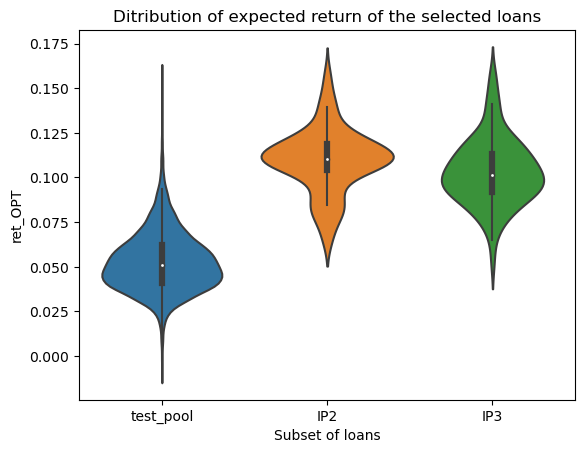

In [43]:
ax = sns.violinplot(y=df_big["predicted_return_ret_OPT"], x=df_big["label"], 
                    data=df_big, order=['test_pool','IP2','IP3'])
ax.set_title("Ditribution of expected return of the selected loans")
ax.set_xlabel("Subset of loans")
ax.set_ylabel("ret_OPT")

Text(0, 0.5, 'ret_OPT')

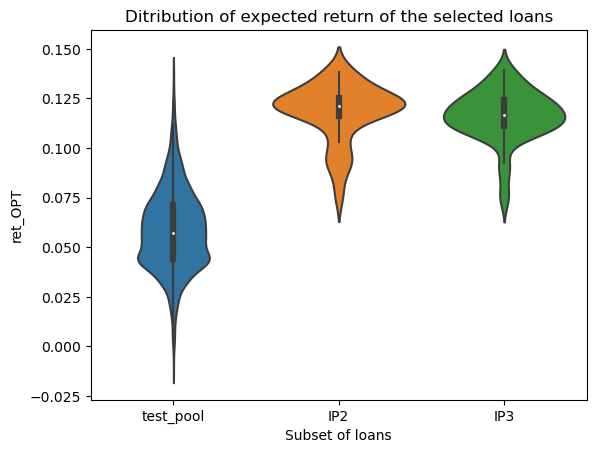

In [87]:
ax = sns.violinplot(y=df_big["predicted_return_ret_OPT"], x=df_big["label"], 
                    data=df_big, order=['test_pool','IP2','IP3'])
ax.set_title("Ditribution of expected return of the selected loans")
ax.set_xlabel("Subset of loans")
ax.set_ylabel("ret_OPT")

## 5.4. Sensitivity analysis of the optimization solution by varying the budgets and the number of loans invested in
Build a trade-off curve between the beta value and the optimization objective (expected return). For this we loop through various values of beta from 0.1 through some large number in steps of 0.1 say. Then we create a plot of different pairs of means and stdevns of the expected return of the portfolios as you vary beta. The two axes will then be mean (return) and stdevn (risk).

In [88]:
num_var = test_pool.shape[0]
Budget = 1000000
beta_min = 0.1
step = 0.1
num_beta = 10
u = np.zeros(num_var) # units vector

for i in range(num_var):
    u[i] = 1

amt = pd.Series(test_pool[0:num_var].loan_amnt)

table = np.zeros([num_beta,2]) # store the return and risk

env = gp.Env(empty=True)
env.setParam('WLSACCESSID', '9f11ef5f-f6b2-424f-b878-41f86258c5da')
env.setParam('WLSSECRET', 'd898d09a-1223-4a71-931b-8800234f87c1')
env.setParam('LICENSEID', 2415696)
env.start()

for j in range(num_beta):
    beta = beta_min + j*step
    
    c = np.zeros(num_var) # cost vector
    for i in range(num_var):
        c[i] = (test_pool['predicted_return_'+  ret_col].iloc[i] - beta * test_pool.volatility.iloc[i]) * test_pool.loan_amnt.iloc[i]
        #c[i] = (test_pool[ret_col].iloc[i] - beta * test_pool.volatility.iloc[i]) * test_pool.loan_amnt.iloc[i]
        #c[i] = (test_pool['score'].iloc[i])
        #c[i] = test_pool['predicted_return_'+ret_col].iloc[i]*test_pool.funded_amnt.iloc[i]
    with gp.Model(env=env) as model:

        x = pd.Series(model.addVars(num_var,vtype=GRB.BINARY))

        model.setObjective(c.dot(x), GRB.MAXIMIZE)
    
        model.addConstr(u.dot(x) <= num_loans)
        model.addConstr(u.dot(x) >= 0.9*num_loans)
        model.addConstr(amt.dot(x) <= Budget)

        model.optimize() 
    
        opt = np.zeros(num_var)
        for k in range(num_var):
            opt[k] = x[k].X
        test_pool['chosen'] = opt
        df = test_pool[test_pool.chosen == 1]
        
        table[j,0] = df['predicted_return_'+  ret_col].sum()
        table[j,1] = df.volatility.sum()
        #table[j,1] = df['score'].sum()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2415696
Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[rosetta2])

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Academic license - for non-commercial use only - registered to xiaohanf@andrew.cmu.edu
Optimize a model with 3 rows, 10000 columns and 30000 nonzeros
Model fingerprint: 0x3813a878
Variable types: 0 continuous, 10000 integer (10000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+04]
  Objective range  [3e-02, 4e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+01, 1e+06]
Presolve time: 0.02s
Presolved: 3 rows, 10000 columns, 30000 nonzeros
Variable types: 0 continuous, 10000 integer (10000 binary)
Found heuristic solution: objective 89639.662744

Root relaxation: objective 1.150469e+05, 9 iterations, 0.00 seconds (0.00 work 

Optimize a model with 3 rows, 10000 columns and 30000 nonzeros
Model fingerprint: 0x2b328cae
Variable types: 0 continuous, 10000 integer (10000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+04]
  Objective range  [8e-02, 3e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [9e+01, 1e+06]
Presolve time: 0.02s
Presolved: 3 rows, 10000 columns, 30000 nonzeros
Variable types: 0 continuous, 10000 integer (10000 binary)
Found heuristic solution: objective 56725.429305

Root relaxation: objective 7.344181e+04, 8 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 73441.8062    0    2 56725.4293 73441.8062  29.5%     -    0s
H    0     0                    73358.019518 73441.8062  0.11%     -    0s
H    0     0                    73390.377144 73441.8062  0.07%     -    0s
H    0     0                    73430.480913 7

     0     0 43667.9572    0    2 43662.3198 43667.9572  0.01%     -    0s
     0     0 43667.9572    0    2 43662.3198 43667.9572  0.01%     -    0s
     0     0 43667.9572    0    2 43662.3198 43667.9572  0.01%     -    0s
     0     0 43667.9572    0    4 43662.3198 43667.9572  0.01%     -    0s
     0     0 43666.8242    0    5 43662.3198 43666.8242  0.01%     -    0s
     0     0 43666.6329    0    6 43662.3198 43666.6329  0.01%     -    0s

Cutting planes:
  Cover: 2
  MIR: 1
  RLT: 1

Explored 1 nodes (23 simplex iterations) in 0.18 seconds (0.13 work units)
Thread count was 8 (of 8 available processors)

Solution count 4: 43662.3 43658.9 43599 33573.3 

Optimal solution found (tolerance 1.00e-04)
Best objective 4.366231981094e+04, best bound 4.366663291318e+04, gap 0.0099%


### Visualization: Return vs Risk curve

In [46]:
table

array([[9.8090629 , 8.12788423],
       [9.77568536, 7.88665186],
       [9.67738201, 7.44006811],
       [9.65583809, 7.3361149 ],
       [9.60672105, 7.20844574],
       [9.59413775, 7.10337095],
       [9.50261795, 6.92790109],
       [9.43993269, 6.82580579],
       [9.37724094, 6.77970032],
       [9.30235578, 6.68837469]])

In [89]:
table

array([[10.88424163,  8.23029415],
       [10.85765962,  7.75993348],
       [10.79486444,  7.61091456],
       [10.60756077,  7.30143849],
       [10.52719947,  7.14308791],
       [10.45716912,  6.96809306],
       [10.38506426,  6.86143131],
       [10.32816852,  6.77685385],
       [10.23493261,  6.66094513],
       [10.17904375,  6.59227747]])

In [93]:
table[:,0]

array([10.88424163, 10.85765962, 10.79486444, 10.60756077, 10.52719947,
       10.45716912, 10.38506426, 10.32816852, 10.23493261, 10.17904375])

In [94]:
table[:,1]

array([8.23029415, 7.75993348, 7.61091456, 7.30143849, 7.14308791,
       6.96809306, 6.86143131, 6.77685385, 6.66094513, 6.59227747])

Text(0, 0.5, 'risk')

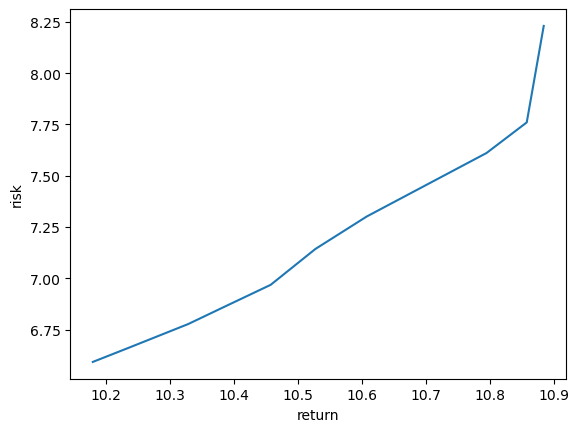

In [96]:
from IPython.display import display, HTML
display(HTML("<style>.container { height:100% !important; }</style>"))
plt.plot(table[:,0],table[:,1])
plt.xlabel("return")
plt.ylabel("risk")